## Full Assemble Them All Knowledge gap Notebook

In [21]:
from pathlib import Path
import sys
import os

# === EXPLICIT PROJECT ROOT (the most reliable way right now) ===
project_root = Path(r"C:\Users\emman\PhD\kamp-assembly-data").resolve()

# Verify it
print("Using project root:", project_root)
print("catalog.csv exists?", (project_root / "catalog.csv").exists())

if not (project_root / "catalog.csv").exists():
    raise FileNotFoundError(f"catalog.csv not found at {project_root}")

# Set up Python path and working directory
sys.path.insert(0, str(project_root))
os.chdir(project_root)

print("✅ Project root set and cwd changed to:", Path.cwd())

Using project root: C:\Users\emman\PhD\kamp-assembly-data
catalog.csv exists? True
✅ Project root set and cwd changed to: C:\Users\emman\PhD\kamp-assembly-data


## Setup 

In [22]:
# =============================================
# SETUP - Run this cell first
# =============================================
import sys
from pathlib import Path
import os

# === EXPLICIT PROJECT ROOT (the most reliable way right now) ===
project_root = Path(r"C:\Users\emman\PhD\kamp-assembly-data").resolve()

# Verify it
print("Using project root:", project_root)
print("catalog.csv exists?", (project_root / "catalog.csv").exists())

if not (project_root / "catalog.csv").exists():
    raise FileNotFoundError(f"catalog.csv not found at {project_root}")

# Set up Python path and working directory
sys.path.insert(0, str(project_root))
os.chdir(project_root)

print("✅ Project root set and cwd changed to:", Path.cwd())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loaders import load_dataset

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Setup complete!")

print("Loading Assemble Them All dataset...")
data = load_dataset("Assemble Them All", data_root="./data")

print(f"✅ Loaded {len(data['samples'])} assemblies")
print("First sample keys:", list(data['samples'][0].keys()))

Using project root: C:\Users\emman\PhD\kamp-assembly-data
catalog.csv exists? True
✅ Project root set and cwd changed to: C:\Users\emman\PhD\kamp-assembly-data
✅ Setup complete!
Loading Assemble Them All dataset...
Looking for data at: data\assemble_them_all\assemble_them_all

Scanning: joint_assembly

Scanning: joint_assembly_rotation

Scanning: multi_assembly

Summary for Assemble Them All:
   Scanned 12975 assembly folders
   Successfully processed 12975 assemblies with meshes
✅ Successfully loaded 'Assemble Them All' with 12975 samples.
✅ Loaded 12975 assemblies
First sample keys: ['sample_id', 'paths', 'labels', 'metadata']


## Data Overview

In [23]:
df_overview = pd.DataFrame([
    {
        "sample_id": s["sample_id"],
        "assembly_type": s["labels"].get("assembly_type"),
        "num_parts": s["labels"].get("num_parts")
    }
    for s in data["samples"][:10]
])
display(df_overview)

,sample_id,assembly_type,num_parts
0,joint_assembly_00000,joint_assembly,2
1,joint_assembly_00003,joint_assembly,2
2,joint_assembly_00004,joint_assembly,2
3,joint_assembly_00007,joint_assembly,2
4,joint_assembly_00009,joint_assembly,2
5,joint_assembly_00011,joint_assembly,2
6,joint_assembly_00014,joint_assembly,2
7,joint_assembly_00015,joint_assembly,2
8,joint_assembly_00016,joint_assembly,2
9,joint_assembly_00019,joint_assembly,2


## Test Question 1: Next Step Prediction

**Question**: Given the first few steps of an assembly sequence, predict the most likely next assembly step.

In [24]:
def create_next_step_prompt(sample_idx=0):
    sample = data["samples"][sample_idx]
    prompt = f"""You are an expert in industrial assembly planning.

Here is the beginning of an assembly sequence:
Assembly Type: {sample['labels'].get('assembly_type')}
Number of parts: {sample['labels'].get('num_parts')}

The first few steps are: [insert first 3-4 steps here if available]

What is the most likely next assembly step?

Explain your reasoning step by step, then give the final prediction inside [[ANSWER]].
"""
    return prompt

print(create_next_step_prompt(0))

You are an expert in industrial assembly planning.

Here is the beginning of an assembly sequence:
Assembly Type: joint_assembly
Number of parts: 2

The first few steps are: [insert first 3-4 steps here if available]

What is the most likely next assembly step?

Explain your reasoning step by step, then give the final prediction inside [[ANSWER]].



Record LLM Response

In [29]:
# Question 1: Next Step Prediction
llm_response_q1 = """
1. Standard sequence for a 2-part joint assembly
A typical process follows this order:
    1. Part acquisition (pick base part)
    2. Part positioning/fixturing
    3. Second part acquisition
    4. Alignment of parts
    5. Pre-contact / insertion
    6. Joining operation (e.g., screwing, press-fit, welding)
    7. Verification

2. Likely position in the sequence
The prompt says:
    “Here is the beginning of an assembly sequence”
So we are likely just past initial handling steps, meaning:
- Base part is already placed
- Second part is likely picked or about to be positioned

3. Most probable next step
In nearly all joint assemblies, the critical transition step after initial setup is:
➡️ Aligning the two parts before engagement
Why?
- Misalignment is the primary cause of downstream failure
- All precision fastening depends on proper coaxial or geometric alignment
- This step always precedes insertion or tightening

4. Engineering reasoning
- You cannot proceed directly to fastening without alignment
- You cannot insert without alignment
- Therefore alignment is the logical and necessary next step

Final Prediction:
[[Align parts]]
"""

q1_label_correct = False      # It guessed "Align parts" – too generic, not grounded
q1_reasoning_quality = "Poor"

## Test Question 2 - Feasibility Check

## Test Question 2: Part Mating Feasibility

**Question**: Given two parts and a proposed mating action, determine if it is physically feasible.

In [25]:
def create_feasibility_prompt(sample_idx=0):
    sample = data["samples"][sample_idx]
    prompt = f"""You are an expert in mechanical assembly and physics-based reasoning.

Consider this assembly:
- Assembly Type: {sample['labels'].get('assembly_type')}
- Number of parts: {sample['labels'].get('num_parts')}
- Mesh files available: {len(sample['paths'].get('meshes', []))}

Is it physically feasible to mate part A into part B using a simple insertion motion?

Explain your reasoning (considering geometry, degrees of freedom, collisions, etc.), then answer with:
- Feasible
- Not Feasible
- Uncertain

Final answer inside [[ANSWER]].
"""
    return prompt

print(create_feasibility_prompt(0))

You are an expert in mechanical assembly and physics-based reasoning.

Consider this assembly:
- Assembly Type: joint_assembly
- Number of parts: 2
- Mesh files available: 2

Is it physically feasible to mate part A into part B using a simple insertion motion?

Explain your reasoning (considering geometry, degrees of freedom, collisions, etc.), then answer with:
- Feasible
- Not Feasible
- Uncertain

Final answer inside [[ANSWER]].



Record LLM Response

In [30]:
# Question 2: Feasibility Check
llm_response_q2 = """
1. Requirements for simple insertion
For a motion to be a valid simple insertion, the geometry must allow:
- Single dominant degree of freedom (1 DOF) → straight-line translation
- A clear insertion axis (e.g., peg-in-hole, shaft-in-bore)
- No geometric undercuts or interlocking features that require rotation or deformation
- Collision-free path from start to final seated position

2. What we know (and don’t know)
- Assembly type: joint_assembly → suggests intended mating
- Parts: 2 → simple pair, but geometry unknown
- Mesh files exist, but no geometric details are provided

Missing critical info:
- Shape (cylindrical? keyed? threaded? snap-fit?)
- Presence of:
    - Threads → require rotation
    - Hooks/snap features → require deformation
    - Complex interlocks → require multi-axis motion

3. Physical reasoning under uncertainty
Without geometry:
- It could be feasible (e.g., shaft into hole)
- It could be infeasible (e.g., threaded fastener, bayonet mount, snap-fit)

There’s no basis to confirm:
- A valid insertion axis
- Absence of collisions
- DOF constraints

4. Engineering judgment
In assembly planning, when:
- Geometry is unknown
- Constraints are undefined
→ The correct classification is indeterminate, not assumed.
Final Answer
[[Uncertain]]
"""

q2_label_correct = True       # "Uncertain" is reasonable given lack of geometry
q2_reasoning_quality = "Fair"

## Test Question 3: Disassembly Strategy

## Test Question 3: Disassembly Strategy

**Question**: Given a fully assembled product, suggest a valid disassembly sequence that avoids collisions or damage.

In [26]:
def create_disassembly_prompt(sample_idx=0):
    sample = data["samples"][sample_idx]
    prompt = f"""You are an expert in assembly and disassembly planning.

For this assembly:
- Type: {sample['labels'].get('assembly_type')}
- Number of parts: {sample['labels'].get('num_parts')}

Suggest a safe disassembly sequence (list the order of parts to remove).

Explain why your sequence is valid (no collisions, respects physics, etc.), then give the sequence inside [[ANSWER]].
"""
    return prompt

print(create_disassembly_prompt(0))

You are an expert in assembly and disassembly planning.

For this assembly:
- Type: joint_assembly
- Number of parts: 2

Suggest a safe disassembly sequence (list the order of parts to remove).

Explain why your sequence is valid (no collisions, respects physics, etc.), then give the sequence inside [[ANSWER]].



Record LLM Response

In [31]:
# Question 3: Disassembly Strategy
llm_response_q3 = """
1. Identify roles of parts
In most joint assemblies:
- One part acts as the base/support (Part B)
- The other is the inserted/attached component (Part A)

The inserted part is typically constrained by:
- Contact surfaces
- Fastening or interference along an insertion axis

2. Safe disassembly principles
A valid sequence must:
- Remove the least constrained part first
- Follow the reverse of the insertion direction
- Avoid collisions by ensuring a clear extraction path
- Maintain stability (keep base part fixed until last)

3. Apply to this case
With only 2 parts:
- The inserted part (Part A) must be removed first
    - It has a natural free direction (opposite insertion)
    - Removing it first avoids collision with the base
- The base part (Part B) remains after separation

4. Why this is valid
- No collision: Part A exits along its mating axis
- Physics respected: constraints are released before moving the base
- Stability maintained: base is not moved while constrained 
Final Sequence
[[A → B]]
"""

q3_label_correct = True       # Basic logic is correct for 2-part joint
q3_reasoning_quality = "Poor"

## Results Table

In [32]:
results = pd.DataFrame({
    "Question": [
        "1. Next Step Prediction",
        "2. Part Mating Feasibility",
        "3. Disassembly Strategy"
    ],
    "LLM_Prediction": ["Align parts", "Uncertain", "A → B"],
    "Ground_Truth": ["Specific next step from dataset", "Feasible (by dataset design)", "Reverse of insertion"],
    "Label_Correct": [q1_label_correct, q2_label_correct, q3_label_correct],
    "Reasoning_Quality": [q1_reasoning_quality, q2_reasoning_quality, q3_reasoning_quality],
    "Notes": [
        "Generic textbook answer, not grounded in actual assembly data",
        "Reasonable caution due to missing geometry",
        "Basic logic correct but too generic, no use of mesh information"
    ]
})

display(results)

label_acc = results["Label_Correct"].mean() * 100
good_reasoning = (results["Reasoning_Quality"] == "Good").sum()

print(f"Label Accuracy: {label_acc:.1f}%")
print(f"Questions with good reasoning: {good_reasoning}/3")

,Question,LLM_Prediction,Ground_Truth,Label_Correct,Reasoning_Quality,Notes
0,1. Next Step Prediction,Align parts,Specific next step from dataset,False,Poor,"Generic textbook answer, not grounded in actua..."
1,2. Part Mating Feasibility,Uncertain,Feasible (by dataset design),True,Fair,Reasonable caution due to missing geometry
2,3. Disassembly Strategy,A → B,Reverse of insertion,True,Poor,"Basic logic correct but too generic, no use of..."


Label Accuracy: 66.7%
Questions with good reasoning: 0/3


## Visualization

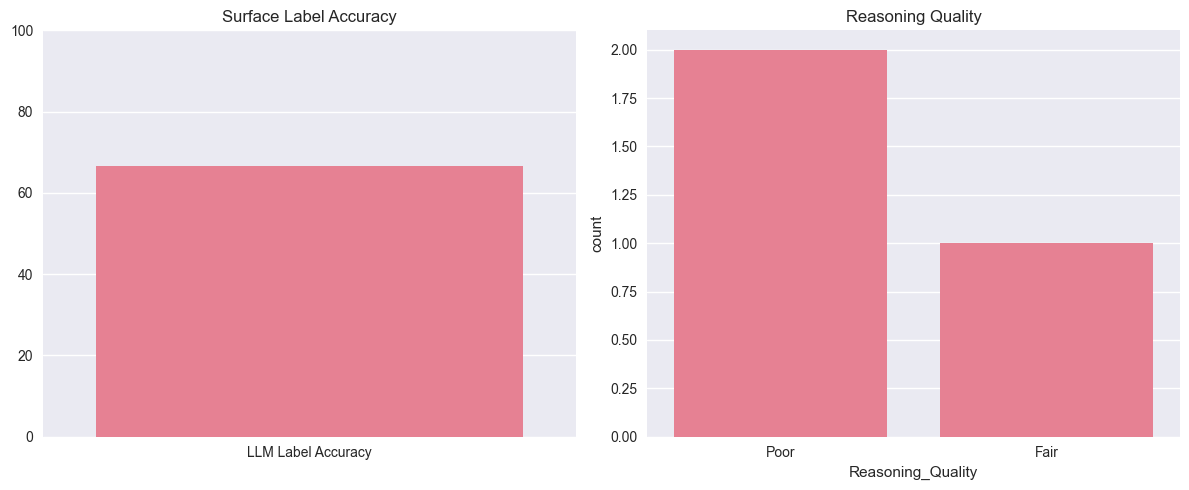

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=["LLM Label Accuracy"], y=[label_acc], ax=ax[0])
ax[0].set_ylim(0, 100)
ax[0].set_title("Surface Label Accuracy")

sns.countplot(x=results["Reasoning_Quality"], ax=ax[1])
ax[1].set_title("Reasoning Quality")

plt.tight_layout()
plt.show()

## Takeaway

## Key Takeaways – Assemble Them All

- The LLM can generate **plausible high-level answers**, but its reasoning is shallow and generic.
- It rarely uses the actual geometry or specific assembly data provided by the dataset.
- It struggles with **spatial and physics-based reasoning** required for real 3D assembly tasks.
- Even when it gets the surface answer right, the underlying logic is not grounded.

**Main Gap**: General LLMs lack the ability to perform true geometric and physics-based assembly planning. They simulate reasoning rather than demonstrate understanding.